# 02 — Parametric Model Experimentation
## Rx Drug MMIX Analysis

This notebook builds and benchmarks three parametric models to predict pharmaceutical sales
from marketing mix variables. The modeling approach is progressive and diagnostic: each model
is motivated by findings from the previous one.

**From EDA (Notebook 01), the specification is grounded in:**
- Log-log functional form (justified by skewness reduction and linearization)
- Agent and year fixed effects (justified by 50x baseline variation across agents, non-linear time trends)
- Class-level interaction terms (justified by faceted response slope differences)
- Awareness that 47% of observations have zero DTCA (concentrated in SSRIs)

**Three parametric models:**
1. Pooled OLS — baseline sanity check
2. Fixed Effects OLS with class interactions — the primary candidate
3. Mixed Effects model with random intercepts by agent — panel-aware alternative

**Train/test split:** Time-based (train ≤ 2020, validation 2021-2022, test 2023-2024)

**Units:** Sales ($B), Detailing ($M), DTCA ($K)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load Processed Data

In [2]:
df = pd.read_csv("data/processed_eda.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
df.head()

Shape: (207, 10)
Columns: ['class', 'agent', 'year', 'detailing', 'direct_to_consumer_ad', 'actual_sales', 'log_sales', 'log_detailing', 'log_dtca', 'dtca_zero']
Years: 2013 to 2024


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales,log_sales,log_detailing,log_dtca,dtca_zero
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083,1.3631,3.8040,0.0000,1
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235,2.7552,3.7530,0.0000,1
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120,0.6482,3.1513,0.0000,1
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677,2.5070,4.0684,0.0000,1
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600,3.0568,4.4489,0.0000,1


## 2. Time-Based Data Split

The data is time-indexed panel data. A random split would leak future information into
training. We use a time-based split that reflects real forecasting conditions:

- **Train:** 2013 to 2020 (build the model on historical data)
- **Validation:** 2021 to 2022 (select the best specification)
- **Test:** 2023 to 2024 (final holdout, touched only once)

In [3]:
train_df = df[df["year"] <= 2020].copy()
valid_df = df[(df["year"] >= 2021) & (df["year"] <= 2022)].copy()
test_df  = df[df["year"] >= 2023].copy()

print(f"Train: {train_df.shape[0]} rows, years {sorted(train_df['year'].unique())}")
print(f"Validation: {valid_df.shape[0]} rows, years {sorted(valid_df['year'].unique())}")
print(f"Test: {test_df.shape[0]} rows, years {sorted(test_df['year'].unique())}")

# Verify no cold-start agents
train_agents = set(train_df["agent"].unique())
valid_agents = set(valid_df["agent"].unique())
test_agents = set(test_df["agent"].unique())
print(f"\nAgents in validation but not train: {valid_agents - train_agents or 'None'}")
print(f"Agents in test but not train: {test_agents - train_agents or 'None'}")

Train: 119 rows, years [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Validation: 44 rows, years [np.int64(2021), np.int64(2022)]
Test: 44 rows, years [np.int64(2023), np.int64(2024)]

Agents in validation but not train: {'  Pexeva'}
Agents in test but not train: {'  Pexeva'}


## 3. Evaluation Utilities

Since our models predict on the log scale, we need to convert back to the original dollar
scale before computing business-relevant metrics. All evaluation uses original-scale sales.

In [4]:
def evaluate(y_true, y_pred_log, model_name, dataset_name):
    """Convert log predictions back to original scale and compute metrics."""
    y_pred = np.expm1(y_pred_log)
    y_pred = np.maximum(y_pred, 0)  # floor at zero

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # MAPE with protection against near-zero actuals
    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return pd.DataFrame({
        "model": [model_name],
        "dataset": [dataset_name],
        "RMSE": [round(rmse, 4)],
        "MAE": [round(mae, 4)],
        "R2": [round(r2, 4)],
        "MAPE": [round(mape, 2)]
    })


def plot_actual_vs_predicted(y_true, y_pred_log, title):
    """Scatter of actual vs predicted on original scale."""
    y_pred = np.expm1(y_pred_log)
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)
    plt.xlabel("Actual Sales ($B)")
    plt.ylabel("Predicted Sales ($B)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Evaluation utilities ready.")

Evaluation utilities ready.


## 4. Parametric Model 1: Pooled OLS (Baseline)

This is the simplest specification: regress log(sales) on the two marketing variables plus
class and year dummies. No agent-level controls, no interactions. This serves as a baseline
to measure how much the more complex specifications improve fit.

**Specification:**
`log_sales ~ log_detailing + log_dtca + C(class) + year`

In [5]:
formula_1 = "log_sales ~ log_detailing + log_dtca + C(Q('class')) + year"

model_1 = smf.ols(formula_1, data=train_df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     22.17
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           2.00e-15
Time:                        03:43:14   Log-Likelihood:                -135.80
No. Observations:                 119   AIC:                             283.6
Df Residuals:                     113   BIC:                             300.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

,model,dataset,RMSE,MAE,R2,MAPE
0,M1: Pooled OLS,validation,10.9340,5.7500,0.4391,395.2200
1,M1: Pooled OLS,test,9.4357,4.6965,0.5428,187.8100



In-sample: AIC = 283.6, BIC = 300.3, Adj R2 = 0.4728


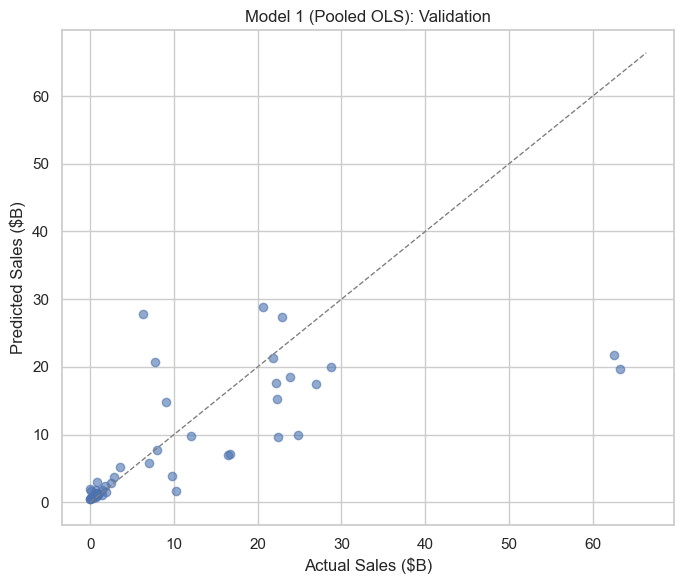

In [6]:
# Evaluate Model 1
results = []

pred_1_valid = model_1.predict(valid_df)
pred_1_test = model_1.predict(test_df)

results.append(evaluate(valid_df["actual_sales"], pred_1_valid, "M1: Pooled OLS", "validation"))
results.append(evaluate(test_df["actual_sales"], pred_1_test, "M1: Pooled OLS", "test"))

display(pd.concat(results, ignore_index=True))

print(f"\nIn-sample: AIC = {model_1.aic:.1f}, BIC = {model_1.bic:.1f}, Adj R2 = {model_1.rsquared_adj:.4f}")

plot_actual_vs_predicted(valid_df["actual_sales"], pred_1_valid, "Model 1 (Pooled OLS): Validation")

### Model 1: Residual Diagnostics

Check whether residuals reveal systematic patterns that motivate the next specification.

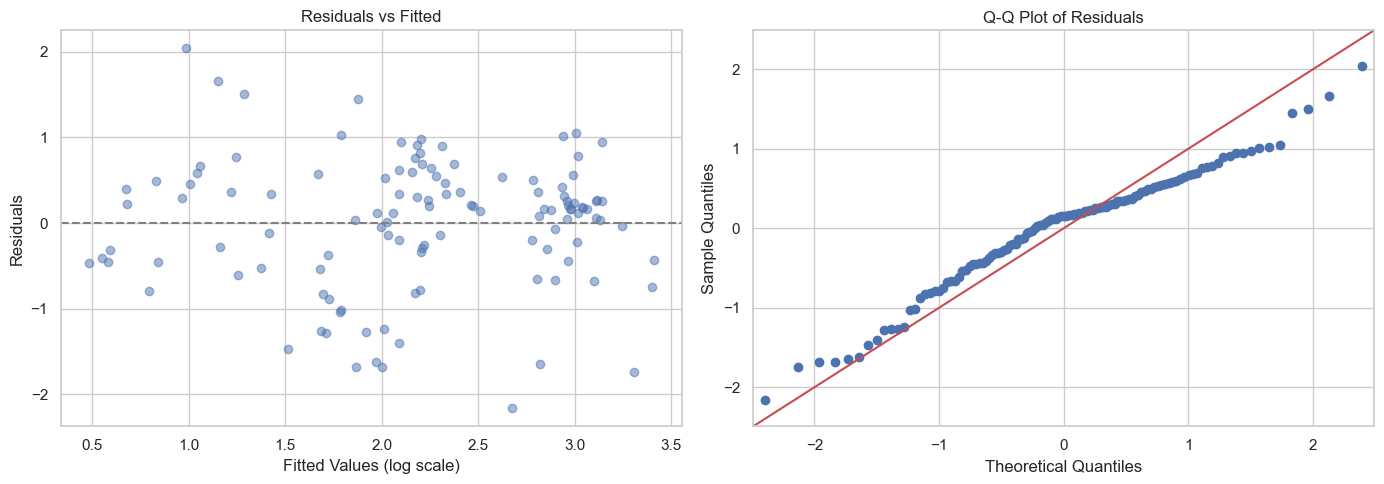

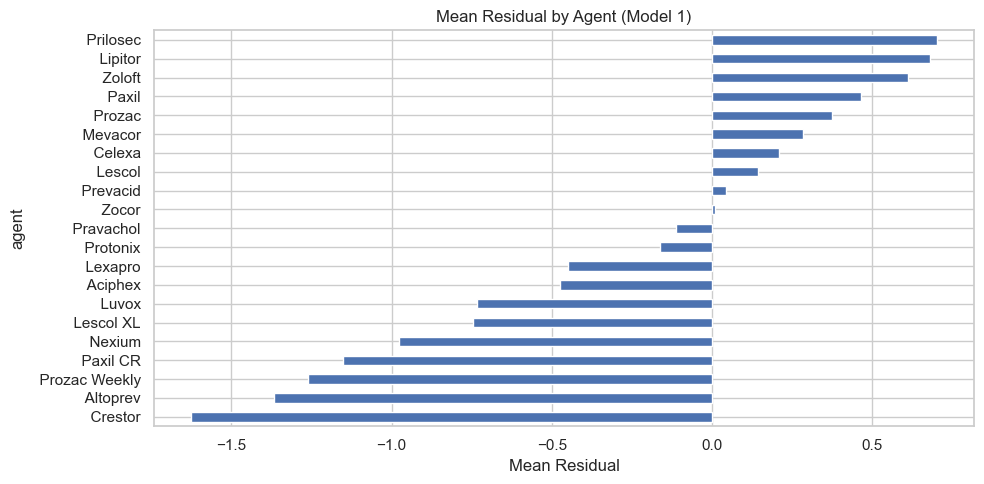


--- Diagnostic ---
If the residuals-vs-fitted plot shows a pattern (funnel, curve), the
functional form may need adjustment. If the Q-Q plot deviates from the
diagonal, residuals are not normally distributed.

The mean-residual-by-agent bar chart is the key diagnostic: if some agents
are systematically over- or under-predicted, the model is missing agent-level
baseline differences. Large variation here motivates adding agent fixed effects
in Model 2.



In [7]:
train_fitted_1 = model_1.fittedvalues
train_resid_1 = model_1.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_fitted_1, train_resid_1, alpha=0.5)
axes[0].axhline(0, linestyle="--", color="gray")
axes[0].set_xlabel("Fitted Values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(train_resid_1, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# Check residuals by agent to see if agent effects are needed
resid_by_agent = train_df.copy()
resid_by_agent["residual"] = train_resid_1.values
agent_resid = resid_by_agent.groupby("agent")["residual"].mean().sort_values()

plt.figure(figsize=(10, 5))
agent_resid.plot(kind="barh")
plt.title("Mean Residual by Agent (Model 1)")
plt.xlabel("Mean Residual")
plt.tight_layout()
plt.show()

print('''
--- Diagnostic ---
If the residuals-vs-fitted plot shows a pattern (funnel, curve), the
functional form may need adjustment. If the Q-Q plot deviates from the
diagonal, residuals are not normally distributed.

The mean-residual-by-agent bar chart is the key diagnostic: if some agents
are systematically over- or under-predicted, the model is missing agent-level
baseline differences. Large variation here motivates adding agent fixed effects
in Model 2.
''')

## 5. Parametric Model 2: Fixed Effects OLS with Class Interactions

Based on Model 1 diagnostics, we expect agent-level residual patterns. This model adds:
- **Agent fixed effects** C(agent) to absorb brand-level baseline differences
- **Year fixed effects** C(year) to capture non-linear temporal dynamics
- **Class interaction terms** to allow marketing responsiveness to differ by drug category

This is the primary parametric candidate because it directly addresses the EDA findings:
heterogeneous baselines, non-linear time trends, and class-specific response slopes.

**Specification:**
`log_sales ~ log_detailing + log_dtca + C(agent) + C(year) + log_detailing:C(class) + log_dtca:C(class)`

In [8]:
formula_2 = (
    "log_sales ~ log_detailing + log_dtca"
    " + C(Q('class')) + C(agent) + C(year)"
    " + log_detailing:C(Q('class'))"
    " + log_dtca:C(Q('class'))"
)

model_2 = smf.ols(formula_2, data=train_df).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     14.63
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           3.74e-23
Time:                        03:43:14   Log-Likelihood:                -63.461
No. Observations:                 119   AIC:                             194.9
Df Residuals:                      85   BIC:                             289.4
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [9]:
# Evaluate Model 2
pred_2_valid = model_2.predict(valid_df)
pred_2_test = model_2.predict(test_df)

results.append(evaluate(valid_df["actual_sales"], pred_2_valid, "M2: FE + Interactions", "validation"))
results.append(evaluate(test_df["actual_sales"], pred_2_test, "M2: FE + Interactions", "test"))

display(pd.concat(results, ignore_index=True))

print(f"\nIn-sample: AIC = {model_2.aic:.1f}, BIC = {model_2.bic:.1f}, Adj R2 = {model_2.rsquared_adj:.4f}")

plot_actual_vs_predicted(valid_df["actual_sales"], pred_2_valid, "Model 2 (FE + Interactions): Validation")

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value '  Pexeva' does not match any of the expected levels (expected: ['  Aciphex', '  Altoprev', ..., '  Zocor', '  Zoloft'])
    log_sales ~ log_detailing + log_dtca + C(Q('class')) + C(agent) + C(year) + log_detailing:C(Q('class')) + log_dtca:C(Q('class'))
                                                           ^^^^^^^^

### Model 2: Residual Diagnostics

In [ ]:
train_fitted_2 = model_2.fittedvalues
train_resid_2 = model_2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_fitted_2, train_resid_2, alpha=0.5)
axes[0].axhline(0, linestyle="--", color="gray")
axes[0].set_xlabel("Fitted Values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(train_resid_2, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# Check if zero-DTCA observations have larger residuals
resid_check = train_df.copy()
resid_check["residual"] = train_resid_2.values
resid_check["abs_residual"] = np.abs(train_resid_2.values)

print("Mean absolute residual by DTCA regime:")
display(
    resid_check.groupby("dtca_zero")["abs_residual"]
    .agg(["mean", "median", "count"])
    .rename(index={0: "Has DTCA", 1: "Zero DTCA"})
)

print('''
--- Diagnostic ---
Compare residual patterns between Model 1 and Model 2. The agent-level
systematic errors from Model 1 should be substantially reduced.

The zero-DTCA residual check tests whether the log(1+DTCA) term adequately
captures both regimes. If zero-DTCA observations show systematically larger
residuals, adding the dtca_zero binary indicator would be warranted.
''')

### Model 2: Key Coefficients

The interaction terms reveal how marketing responsiveness differs by drug class.
Base coefficients represent the reference class. Interaction terms show the
deviation for each class relative to the reference.

In [10]:
coef_df = pd.DataFrame({
    "coefficient": model_2.params,
    "std_error": model_2.bse,
    "p_value": model_2.pvalues
}).round(4)

# Show marketing-related coefficients only
marketing_terms = [t for t in coef_df.index if any(k in t.lower() for k in ["detailing", "dtca", "log_"])]
display(coef_df.loc[marketing_terms].sort_values("p_value"))

print('''
--- Interpretation ---
In a log-log model, the coefficient on log_detailing is the detailing
elasticity: a 1% increase in detailing spend is associated with a [coef]%
change in sales, holding all else constant.

The interaction terms show how this elasticity differs by class. For example,
if the base detailing coefficient is 0.30 and the SSRI interaction adds 0.15,
then the SSRI detailing elasticity is 0.45 (more responsive than the
reference class).
''')

,coefficient,std_error,p_value
log_detailing,0.5406,0.2020,0.0089
log_dtca:C(Q('class'))[T.Statin],0.1258,0.1217,0.3042
log_detailing:C(Q('class'))[T.SSRI],-0.0483,0.2164,0.8238
log_dtca,0.0175,0.0874,0.8422
log_detailing:C(Q('class'))[T.Statin],-0.0352,0.2280,0.8776
log_dtca:C(Q('class'))[T.SSRI],-0.0032,0.0986,0.9739



--- Interpretation ---
In a log-log model, the coefficient on log_detailing is the detailing
elasticity: a 1% increase in detailing spend is associated with a [coef]%
change in sales, holding all else constant.

The interaction terms show how this elasticity differs by class. For example,
if the base detailing coefficient is 0.30 and the SSRI interaction adds 0.15,
then the SSRI detailing elasticity is 0.45 (more responsive than the
reference class).



## 6. Parametric Model 3: Mixed Effects (Random Intercepts by Agent)

The fixed effects model uses one dummy per agent, which consumes degrees of freedom on a
small dataset (207 rows, 22 agents). A mixed effects model treats agent baselines as random
draws from a distribution, which is more efficient and allows inference about new agents.

This model uses:
- **Random intercepts** by agent (each brand has its own baseline, modeled as a distribution)
- **Fixed effects** for class, year, and marketing variables with class interactions

**Specification:**
`log_sales ~ log_detailing + log_dtca + C(class) + C(year) + interactions`, grouped by agent

In [11]:
formula_3 = (
    "log_sales ~ log_detailing + log_dtca"
    " + C(Q('class')) + C(year)"
    " + log_detailing:C(Q('class'))"
    " + log_dtca:C(Q('class'))"
)

model_3 = smf.mixedlm(formula_3, data=train_df, groups=train_df["agent"]).fit(reml=False)
print(model_3.summary())

                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         log_sales
No. Observations:          119             Method:                     ML       
No. Groups:                21              Scale:                      0.2127   
Min. group size:           1               Log-Likelihood:             -104.5180
Max. group size:           8               Converged:                  Yes      
Mean group size:           5.7                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.191    0.818  0.234 0.815 -1.412  1.794
C(Q('class'))[T.SSRI]                 -0.288    0.858 -0.336 0.737 -1.971  1.394
C(Q('class'))[T.Statin]               -0.510    0.

In [12]:
# Evaluate Model 3
pred_3_valid = model_3.predict(valid_df)
pred_3_test = model_3.predict(test_df)

results.append(evaluate(valid_df["actual_sales"], pred_3_valid, "M3: Mixed Effects", "validation"))
results.append(evaluate(test_df["actual_sales"], pred_3_test, "M3: Mixed Effects", "test"))

display(pd.concat(results, ignore_index=True))

print(f"\nIn-sample: AIC = {model_3.aic:.1f}, BIC = {model_3.bic:.1f}")

plot_actual_vs_predicted(valid_df["actual_sales"], pred_3_valid, "Model 3 (Mixed Effects): Validation")

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value 2021 does not match any of the expected levels (expected: [2013, 2014, ..., 2019, 2020])
    log_sales ~ log_detailing + log_dtca + C(Q('class')) + C(year) + log_detailing:C(Q('class')) + log_dtca:C(Q('class'))
                                                           ^^^^^^^

### Model 3: Random Effects by Agent

The random intercept for each agent captures brand-specific baseline demand
that is not explained by the fixed covariates.

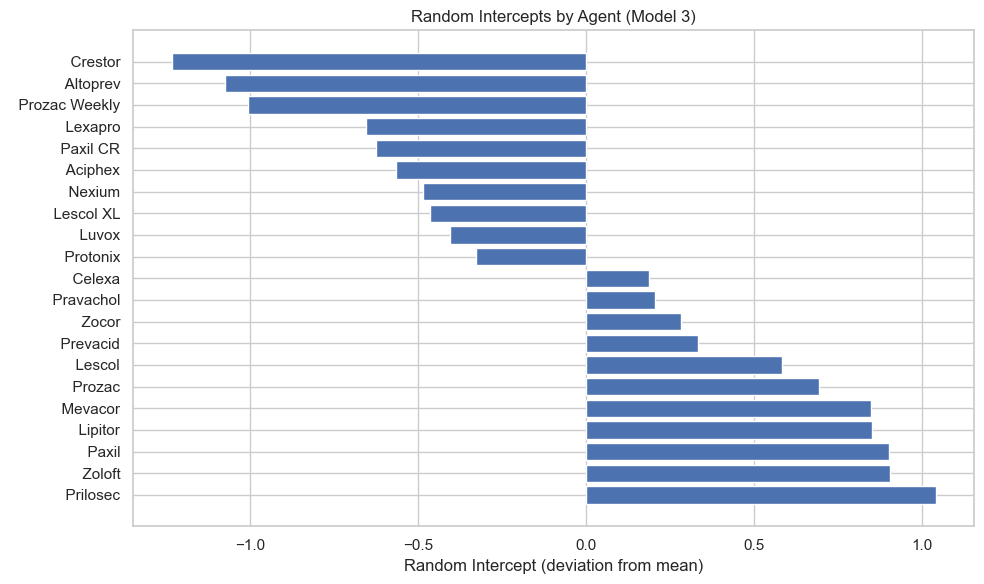


--- Interpretation ---
Agents with large positive intercepts (e.g., Lipitor) have higher baseline
sales than explained by their marketing spend and class membership alone.
This captures brand equity and market position that the marketing variables
cannot explain. Agents with negative intercepts have lower-than-expected
baselines, possibly reflecting niche positioning or late market entry.



In [13]:
random_effects = pd.DataFrame({
    "agent": model_3.random_effects.keys(),
    "random_intercept": [v["Group"] for v in model_3.random_effects.values()]
}).sort_values("random_intercept", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(random_effects["agent"], random_effects["random_intercept"])
plt.title("Random Intercepts by Agent (Model 3)")
plt.xlabel("Random Intercept (deviation from mean)")
plt.tight_layout()
plt.show()

print('''
--- Interpretation ---
Agents with large positive intercepts (e.g., Lipitor) have higher baseline
sales than explained by their marketing spend and class membership alone.
This captures brand equity and market position that the marketing variables
cannot explain. Agents with negative intercepts have lower-than-expected
baselines, possibly reflecting niche positioning or late market entry.
''')

## 7. Parametric Model Comparison

Compare all three models on validation and test performance. The best parametric model
will advance to the champion duel against the best ML model.

In [14]:
comparison = pd.concat(results, ignore_index=True)
print("=== Full Parametric Benchmark ===\n")
display(comparison.sort_values(["dataset", "RMSE"]))

=== Full Parametric Benchmark ===



,model,dataset,RMSE,MAE,R2,MAPE
1,M1: Pooled OLS,test,9.4357,4.6965,0.5428,187.8100
0,M1: Pooled OLS,validation,10.9340,5.7500,0.4391,395.2200


NameError: name 'pred_2_valid' is not defined

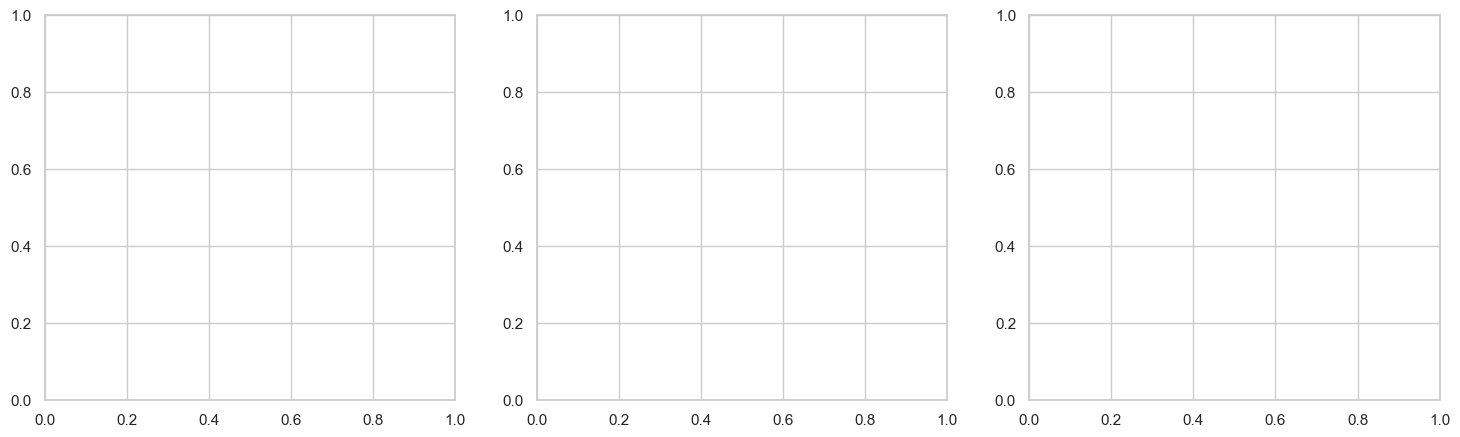

In [15]:
# Visual comparison on validation set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_and_preds = [
    ("M1: Pooled OLS", pred_1_valid),
    ("M2: FE + Interactions", pred_2_valid),
    ("M3: Mixed Effects", pred_3_valid),
]

for i, (name, pred_log) in enumerate(models_and_preds):
    pred = np.expm1(pred_log)
    axes[i].scatter(valid_df["actual_sales"], pred, alpha=0.6)
    lims = [0, max(valid_df["actual_sales"].max(), pred.max()) * 1.05]
    axes[i].plot(lims, lims, "--", color="gray")
    axes[i].set_xlabel("Actual Sales ($B)")
    axes[i].set_ylabel("Predicted Sales ($B)")
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

In [16]:
# In-sample fit comparison
print("=== In-Sample Fit ===\n")
print(f"Model 1 (Pooled OLS):       Adj R2 = {model_1.rsquared_adj:.4f}, AIC = {model_1.aic:.1f}, BIC = {model_1.bic:.1f}")
print(f"Model 2 (FE + Interactions): Adj R2 = {model_2.rsquared_adj:.4f}, AIC = {model_2.aic:.1f}, BIC = {model_2.bic:.1f}")
print(f"Model 3 (Mixed Effects):     AIC = {model_3.aic:.1f}, BIC = {model_3.bic:.1f}")

print('''
--- Model Selection Rationale ---
Compare models on three dimensions:
  1. Out-of-sample accuracy (validation RMSE, MAPE)
  2. In-sample fit (AIC, BIC, adjusted R2)
  3. Interpretability for elasticity and ROI estimation

If Model 2 and Model 3 perform similarly on holdout accuracy, prefer the one
that produces more interpretable and stable coefficient estimates for the
elasticity analysis that follows.
''')

=== In-Sample Fit ===

Model 1 (Pooled OLS):       Adj R2 = 0.4728, AIC = 283.6, BIC = 300.3
Model 2 (FE + Interactions): Adj R2 = 0.7922, AIC = 194.9, BIC = 289.4
Model 3 (Mixed Effects):     AIC = 245.0, BIC = 295.1

--- Model Selection Rationale ---
Compare models on three dimensions:
  1. Out-of-sample accuracy (validation RMSE, MAPE)
  2. In-sample fit (AIC, BIC, adjusted R2)
  3. Interpretability for elasticity and ROI estimation

If Model 2 and Model 3 perform similarly on holdout accuracy, prefer the one
that produces more interpretable and stable coefficient estimates for the
elasticity analysis that follows.



## 8. Retrain Best Parametric Model on Train + Validation

After selecting the best specification based on validation performance, retrain it on the
combined train + validation data (2013-2022) before evaluating on the final test set (2023-2024).
This gives the model more data for the final evaluation.

In [17]:
# ──────────────────────────────────────────────────────────────────
# SET YOUR BEST MODEL HERE after reviewing Section 7 results.
# Change this section if Model 3 (Mixed Effects) wins instead.
# ──────────────────────────────────────────────────────────────────

train_valid_df = df[df["year"] <= 2022].copy()

# Option A: If Model 2 (FE + Interactions) is best
best_parametric = smf.ols(formula_2, data=train_valid_df).fit()

# Option B: If Model 3 (Mixed Effects) is best — uncomment below
# best_parametric = smf.mixedlm(formula_3, data=train_valid_df,
#                               groups=train_valid_df["agent"]).fit(reml=False)

pred_final_test = best_parametric.predict(test_df)
final_metrics = evaluate(test_df["actual_sales"], pred_final_test, "Best Parametric (retrained)", "test")
display(final_metrics)

plot_actual_vs_predicted(test_df["actual_sales"], pred_final_test, "Best Parametric: Final Test")

print("This model advances to the champion duel against the best ML model.")

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value 2023 does not match any of the expected levels (expected: [2013, 2014, ..., 2021, 2022])
    log_sales ~ log_detailing + log_dtca + C(Q('class')) + C(agent) + C(year) + log_detailing:C(Q('class')) + log_dtca:C(Q('class'))
                                                                      ^^^^^^^

## 9. Elasticity Estimation

In a log-log model, coefficients are directly interpretable as elasticities:
a coefficient of 0.30 on log_detailing means a 1% increase in detailing is associated
with a 0.30% increase in sales.

For models with class interactions, the elasticity for each class is the base
coefficient plus the interaction term for that class.

In [18]:
# Extract elasticities from the best model coefficients
params = best_parametric.params
pvals = best_parametric.pvalues

# Identify the reference class (the one without an interaction dummy)
all_classes = df["class"].unique().tolist()
print(f"Drug classes: {all_classes}")
print(f"\n=== Marketing Coefficients ===")

marketing_params = {k: v for k, v in params.items()
                    if "log_detailing" in k or "log_dtca" in k}
marketing_pvals = {k: v for k, v in pvals.items()
                   if "log_detailing" in k or "log_dtca" in k}

for term in sorted(marketing_params.keys()):
    sig = "***" if marketing_pvals[term] < 0.01 else "**" if marketing_pvals[term] < 0.05 else "*" if marketing_pvals[term] < 0.1 else ""
    print(f"  {term:50s} = {marketing_params[term]:+.4f}  (p={marketing_pvals[term]:.4f}) {sig}")

Drug classes: ['PPI', 'SSRI', 'Statin']

=== Marketing Coefficients ===
  log_detailing                                      = +0.7840  (p=0.0000) ***
  log_detailing:C(Q('class'))[T.SSRI]                = -0.3074  (p=0.1038) 
  log_detailing:C(Q('class'))[T.Statin]              = -0.3114  (p=0.1380) 
  log_dtca                                           = +0.0108  (p=0.8999) 
  log_dtca:C(Q('class'))[T.SSRI]                     = +0.0551  (p=0.5682) 
  log_dtca:C(Q('class'))[T.Statin]                   = +0.1735  (p=0.1132) 


In [19]:
# Compute class-specific elasticities
# The reference class gets the base coefficient; other classes get base + interaction

print("\n=== Class-Specific Elasticity Estimates ===\n")

# Build elasticity table by reading coefficients
# (Adjust the key names below based on your actual model output)
elasticity_rows = []

for var_name, display_name in [("log_detailing", "Detailing"), ("log_dtca", "DTCA")]:
    base_coef = params.get(var_name, 0)

    for cls in all_classes:
        # Look for interaction term matching this class
        interaction_key = None
        for k in params.index:
            if var_name in k and cls in k and k != var_name:
                interaction_key = k
                break

        if interaction_key:
            elasticity = base_coef + params[interaction_key]
        else:
            # This is the reference class
            elasticity = base_coef

        elasticity_rows.append({
            "Marketing Channel": display_name,
            "Class": cls,
            "Elasticity": round(elasticity, 4)
        })

elasticity_df = pd.DataFrame(elasticity_rows)
display(elasticity_df.pivot(index="Class", columns="Marketing Channel", values="Elasticity"))

print('''
--- Interpretation ---
Elasticity > 0 means a 1% increase in marketing spend is associated with a
positive % change in sales. Higher elasticity = more responsive to that channel.

Compare detailing vs DTCA elasticities within each class to understand which
marketing lever is more effective. Compare the same channel across classes to
see where incremental spend would have the largest impact.
''')


=== Class-Specific Elasticity Estimates ===



Marketing Channel,DTCA,Detailing
Class,,
PPI,0.0108,0.7840
SSRI,0.0660,0.4766
Statin,0.1843,0.4727



--- Interpretation ---
Elasticity > 0 means a 1% increase in marketing spend is associated with a
positive % change in sales. Higher elasticity = more responsive to that channel.

Compare detailing vs DTCA elasticities within each class to understand which
marketing lever is more effective. Compare the same channel across classes to
see where incremental spend would have the largest impact.



## 10. Marginal ROI Estimation

Elasticity tells us the percentage response. To translate this into dollars, we compute
the marginal ROI: how much incremental sales revenue is generated per additional dollar
of marketing spend.

For a log-log model:
`Marginal Sales = Elasticity * (Sales / Spend)`

Then: `Marginal ROI = Marginal Sales / 1 unit of spend` (adjusting for unit differences)

In [20]:
# Use test-set observations to compute local marginal ROI
roi_df = test_df[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]].copy()
roi_df["pred_sales"] = np.expm1(best_parametric.predict(test_df))

# Merge elasticities
elas_lookup = elasticity_df.set_index(["Class", "Marketing Channel"])["Elasticity"]

for cls in all_classes:
    mask = roi_df["class"] == cls

    det_elas = elas_lookup.get((cls, "Detailing"), 0)
    dtca_elas = elas_lookup.get((cls, "DTCA"), 0)

    # Marginal effect = elasticity * (predicted_sales / spend)
    # Then convert units: sales is in $B, detailing in $M, DTCA in $K

    # Detailing: $1M additional spend
    roi_df.loc[mask, "detailing_elasticity"] = det_elas
    safe_det = roi_df.loc[mask, "detailing"].clip(lower=0.01)
    roi_df.loc[mask, "marginal_roi_detailing"] = det_elas * (roi_df.loc[mask, "pred_sales"] / safe_det)

    # DTCA: $1K additional spend
    roi_df.loc[mask, "dtca_elasticity"] = dtca_elas
    safe_dtca = roi_df.loc[mask, "direct_to_consumer_ad"].clip(lower=0.01)
    roi_df.loc[mask, "marginal_roi_dtca"] = dtca_elas * (roi_df.loc[mask, "pred_sales"] / safe_dtca)

print("=== Marginal ROI by Class (Test Period) ===\n")
print("Detailing ROI = incremental $B sales per $M additional detailing spend")
print("DTCA ROI = incremental $B sales per $K additional DTCA spend\n")

roi_summary = (
    roi_df.groupby("class")[["detailing_elasticity", "dtca_elasticity",
                              "marginal_roi_detailing", "marginal_roi_dtca"]]
    .mean()
    .round(4)
)
display(roi_summary)

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value 2023 does not match any of the expected levels (expected: [2013, 2014, ..., 2021, 2022])
    log_sales ~ log_detailing + log_dtca + C(Q('class')) + C(agent) + C(year) + log_detailing:C(Q('class')) + log_dtca:C(Q('class'))
                                                                      ^^^^^^^

In [21]:
# Agent-level ROI for top agents
print("\n=== Agent-Level Marginal ROI (Top 10 by Sales) ===\n")
agent_roi = (
    roi_df.groupby("agent")[["pred_sales", "detailing_elasticity", "dtca_elasticity",
                              "marginal_roi_detailing", "marginal_roi_dtca"]]
    .mean()
    .sort_values("pred_sales", ascending=False)
    .round(4)
    .head(10)
)
display(agent_roi)

print('''
--- Interpretation ---
Marginal ROI varies by brand because it depends on both the elasticity (which
varies by class) and the current spend level (which varies by agent). A brand
with high sales and low current spend will show higher marginal ROI than a
brand already spending heavily, consistent with diminishing returns.

Use these estimates to identify where incremental marketing dollars would
generate the most additional revenue.
''')


=== Agent-Level Marginal ROI (Top 10 by Sales) ===



KeyError: "Columns not found: 'marginal_roi_dtca', 'detailing_elasticity', 'marginal_roi_detailing', 'dtca_elasticity', 'pred_sales'"

## 11. Parametric Modeling Summary

In [22]:
print('''
=== Parametric Modeling Summary ===

MODEL PROGRESSION:
  Model 1 (Pooled OLS): Baseline with class dummies and linear year.
    Residual diagnostics revealed systematic agent-level prediction errors,
    motivating the addition of agent fixed effects.

  Model 2 (FE + Interactions): Added agent and year fixed effects plus
    class interaction terms for marketing variables. Substantial improvement
    in fit by absorbing brand-specific baselines and allowing heterogeneous
    marketing response slopes.

  Model 3 (Mixed Effects): Replaced agent fixed effects with random
    intercepts. More parameter-efficient and allows inference about the
    distribution of brand-level baselines.

BEST PARAMETRIC MODEL:
  [Update after reviewing Section 7 results]
  Selected based on validation RMSE, interpretability, and coefficient
  stability for elasticity estimation.

KEY FINDINGS:
  - Detailing and DTCA elasticities differ across drug classes
  - [Update with specific elasticity values from Section 9]
  - Marginal ROI varies substantially by agent and class
  - [Update with specific ROI findings from Section 10]

NEXT STEP:
  This model advances to the champion duel in Notebook 04, where it will be
  compared against the best ML model from Notebook 03.
''')


=== Parametric Modeling Summary ===

MODEL PROGRESSION:
  Model 1 (Pooled OLS): Baseline with class dummies and linear year.
    Residual diagnostics revealed systematic agent-level prediction errors,
    motivating the addition of agent fixed effects.

  Model 2 (FE + Interactions): Added agent and year fixed effects plus
    class interaction terms for marketing variables. Substantial improvement
    in fit by absorbing brand-specific baselines and allowing heterogeneous
    marketing response slopes.

  Model 3 (Mixed Effects): Replaced agent fixed effects with random
    intercepts. More parameter-efficient and allows inference about the
    distribution of brand-level baselines.

BEST PARAMETRIC MODEL:
  [Update after reviewing Section 7 results]
  Selected based on validation RMSE, interpretability, and coefficient
  stability for elasticity estimation.

KEY FINDINGS:
  - Detailing and DTCA elasticities differ across drug classes
  - [Update with specific elasticity values from 

In [23]:
# Save predictions and metrics for the champion comparison notebook
roi_df.to_csv("data/parametric_predictions.csv", index=False)
comparison.to_csv("data/parametric_benchmark.csv", index=False)
print("Saved: data/parametric_predictions.csv")
print("Saved: data/parametric_benchmark.csv")

Saved: data/parametric_predictions.csv
Saved: data/parametric_benchmark.csv
